1.导入模型

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch
from torch.utils.data import Dataset, DataLoader,random_split
import numpy as np
import scipy.io as scio
import os
import time
import matplotlib.pyplot as plt

os.environ["CUDA_VISIBLE_DEVICES"]= '0'
print('CUDA TEST :')
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Dataset(Dataset):
    def __init__(self, directory, input_key, target_key,sampled_key,mask_key):
        """
        Args:
            directory (str): 包含.mat文件的文件夹路径。
            input_key (str): mat文件中对应输入信号的键。
            target_key (str): mat文件中对应目标信号(标签)的键。
        """
        self.directory = directory
        self.input_key = input_key
        self.target_key = target_key
        self.sampled_key = sampled_key
        self.mask_key = mask_key
        self.files = [f for f in os.listdir(directory) if f.endswith('.mat')]
    
    def __len__(self):
        # 返回文件的数量
        return len(self.files)
    
    def __getitem__(self, idx):
        # 获取指定索引的文件名
        file_path = os.path.join(self.directory, self.files[idx])
        mat_data = scio.loadmat(file_path)
        
        # 获取输入信号和目标信号
        input_signal = mat_data[self.input_key]
        sampled_signal = mat_data[self.sampled_key]
        mask = mat_data[self.mask_key]
        target_signal = mat_data[self.target_key]
        
        # 转换为PyTorch张量
        input_signal = torch.tensor(input_signal, dtype=torch.float32)  
        sampled_signal = torch.tensor(sampled_signal,dtype = torch.float32)
        target_signal = torch.tensor(target_signal, dtype=torch.float32)
        mask = torch.tensor(mask,dtype=torch.float32)

        return input_signal, target_signal, sampled_signal, mask

class FeedForwardModule(nn.Module):
    def __init__(self, dim, expansion_factor=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * expansion_factor),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim * expansion_factor, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class MultiHeadSelfAttentionModule(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.layer_norm = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x_norm = self.layer_norm(x) # (batch, height_N1, width_150, dim)
        x_norm = x_norm.contiguous()
        x_norm = x_norm.view(x_norm.size(0)*x_norm.size(1),x_norm.size(2),x_norm.size(-1))
        attn_output, _ = self.self_attn(x_norm, x_norm, x_norm)   
        attn_output = attn_output.contiguous()
        attn_output = attn_output.view(-1,x.size(1),x.size(2),attn_output.size(-1))
        return self.dropout(attn_output)

class ConvolutionModule(nn.Module):
    def __init__(self, dim, kernel_size=(7, 7), dropout=0.1):
        super().__init__()
        self.layer_norm = nn.LayerNorm(dim)
        # 修改为 2D 卷积
        self.pointwise_conv1 = nn.Conv2d(dim, dim * 2, kernel_size=1)
        self.glu = nn.GLU(dim=1)
        self.depthwise_conv = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=(kernel_size[0] // 2, kernel_size[1] // 2), groups=dim)
        self.batch_norm = nn.BatchNorm2d(dim)
        self.pointwise_conv2 = nn.Conv2d(dim, dim, kernel_size=1)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # LayerNorm 仍然作用于最后一维
        x_norm = self.layer_norm(x)
        # 转换为 (batch, dim, height, width) 适用于 2D 卷积
        x = x_norm.permute(0, 3, 1, 2)  # (batch, dim, height, width)
        # Pointwise 2D 卷积
        x = self.pointwise_conv1(x)
        
        # GLU 激活
        x = self.glu(x)
        
        # 深度可分离 2D 卷积
        x = self.depthwise_conv(x)
        
        # Batch Normalization
        x = self.batch_norm(x)
        
        # 激活函数
        x = self.activation(x)
        
        # 另一个 Pointwise 2D 卷积
        x = self.pointwise_conv2(x)
        
        # 转回 (batch, height, width, dim)
        x = x.permute(0, 2, 3, 1)  # (batch, height, width, dim)
        
        return self.dropout(x)


class ConformerBlock(nn.Module):
    def __init__(self, dim, num_heads, ff_expansion_factor=4, conv_kernel_size=(7,7), dropout=0.1):
        super().__init__()
        self.ffn_module1 = FeedForwardModule(dim, ff_expansion_factor, dropout)
        self.mhsa_module = MultiHeadSelfAttentionModule(dim, num_heads, dropout)
        self.conv_module = ConvolutionModule(dim, conv_kernel_size, dropout)
        self.ffn_module2 = FeedForwardModule(dim, ff_expansion_factor, dropout)
        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, x):
        # 1st Feed Forward
        x = x + 0.5 * self.ffn_module1(x)
        # # 在mhsa之前添加卷积层  (--------------------修改-------------------)
        # x = x + self.conv_module(x)
        # Multi-Head Self Attention
        x = x + self.mhsa_module(x)
        # Convolution Module
        x = x + self.conv_module(x)
        # 2nd Feed Forward
        x = x + 0.5 * self.ffn_module2(x)
        # Final Layer Norm
        return self.layer_norm(x)

class dc_layer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,input,sampled,mask):
        lambda_mul = 1e6
        _,N1,N2,_ = input.shape
        _,N1_origin,N2_origin,_ = sampled.shape
        real_part = input[:,0:N1_origin,0:N2_origin,0]
        imag_part = input[:,0:N1_origin,0:N2_origin,1]
        complex_input = torch.view_as_complex(torch.stack((real_part, imag_part), dim=-1))
        inverse_fft = torch.fft.ifft2(complex_input)
        rl_inverse = torch.real(inverse_fft)
        im_inverse = torch.imag(inverse_fft)

        inverse_fft = torch.stack((rl_inverse,im_inverse), dim=-1)
        # inverse_fft = (1-mask) * inverse_fft + (mask * inverse_fft + lambda_mul * sampled)/(1+lambda_mul) # 加权叠加
        # print('inverse_fft:',inverse_fft.shape)
        # print('mask:',mask.shape)
        # print('sampled',sampled.shape)
        inverse_fft = (1-mask) * inverse_fft + sampled              # 直接替换
        # inverse_fft = torch.add(inverse_fft,torch.mul(sampled,lambda_mul))/(1+lambda_mul) 
        inverse_fft = inverse_fft.contiguous()   
        x_data_consis = torch.fft.fft2(torch.view_as_complex(inverse_fft))   
        output = torch.stack((torch.real(x_data_consis), torch.imag(x_data_consis)), dim=-1)
        output_pad = torch.zeros((1, N1, N2, 2), dtype=input.dtype, device=input.device)
        output_pad[:, 0:N1_origin, 0:N2_origin, :] = output
        return output_pad


class ConformerNetwork(nn.Module):
    def __init__(self, input_dim=2, model_dim=512, num_heads=8, num_layers=6, ff_expansion_factor=4, conv_kernel_size=31, dropout=0.1):
        super().__init__()
        self.layer_norm = nn.LayerNorm(input_dim)
        self.input_projection = nn.Linear(input_dim, model_dim)
        self.conformer_block1 = nn.ModuleList([
            ConformerBlock(model_dim, num_heads, ff_expansion_factor, conv_kernel_size, dropout)
            for _ in range(num_layers)
        ])
        self.conformer_block2 = nn.ModuleList([
            ConformerBlock(model_dim, num_heads, ff_expansion_factor, conv_kernel_size, dropout)
            for _ in range(num_layers)
        ])
        self.output_projection = nn.Linear(model_dim, input_dim)
        self.dc_layer = dc_layer()

    def forward(self, input, sampled, mask):
        """
        x: Tensor of shape (batch_size,height, width, 2) where the last dimension represents real and imaginary parts
        """
        # 通过多个Conformer块

        x_projection = self.input_projection(input)  # (batch_size,height, width, model_dim)
        for conformer in self.conformer_block1:
            x_conformer1 = conformer(x_projection)
            x_projection = x_conformer1
        output_conformer1 = self.output_projection(x_conformer1)   # (batch_size,height, width, 2)
        output1 = self.dc_layer(output_conformer1,sampled,mask)    

        x_projection = self.input_projection(output1)
        for conformer in self.conformer_block2:
            x_conformer2 = conformer(x_projection)
            x_projection = x_conformer2
        output_conformer2 = self.output_projection(x_conformer2)   # (batch_size,height, width, 2)
        output2 = self.dc_layer(output_conformer2,sampled,mask)

        return output1,output2

# 假设的超参数
input_dim = 2  # 实部和虚部                         
model_dim = 32                                     
num_heads = 2
num_layers = 2                                      # Noise_unfixed.pth    num_layers=3, kernel_size=(5,5)
conv_kernel_size = (17,17)                         # Noise_unfixed_17.pth    num_layers=2, kernel_size=(17,17)
dropout = 0.1
learning_rate = 1e-3
num_epochs = 50
loaded_model = ConformerNetwork(input_dim = input_dim, model_dim = model_dim, num_heads = num_heads, num_layers = num_layers, ff_expansion_factor=4,conv_kernel_size = conv_kernel_size, dropout=dropout)

loaded_model.load_state_dict(torch.load('/mnt/DATA1/linjingjie/Transformer/Code/model_results/Noise_unfixed_17_64x64_10-25.pth'))


CUDA TEST :
True


/tmp/ipykernel_3111026/4286848696.py:231: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('/mnt/DATA1/linjingjie/Transformer/Code/model

<All keys matched successfully>

2. 跨尺寸推理与 RLNE + intensity_linearity 评估

指标见 `utils.py`：**RLNE**（实部相对 L2 误差）；**intensity_linearity** 在 GT 上用 `findpeak_2d(MinA=0.02)` 选峰后，在峰位置比较 |GT| 与 |Recon| 峰高相关。

- **2.0 方阵/跨尺寸**（Cell 3）：`32x32/`、`48x48/`、`64x64/` 等
- **2.1 非方阵转置对比**（Cell 4）：`transpose_size/36x48/` 等，比较原方向 vs H/W 转置输入（同步转置 mask 与采样点，输出转回后再与 GT 比指标）

评估尺寸目录: {'32x32': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/32x32', '36x36': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/36x36', '48x48': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/48x48', '64x64': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/64x64', '128x128': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/128x128', '256x256': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/256x256', '384x384': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/384x384', '512x512': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/512x512'}


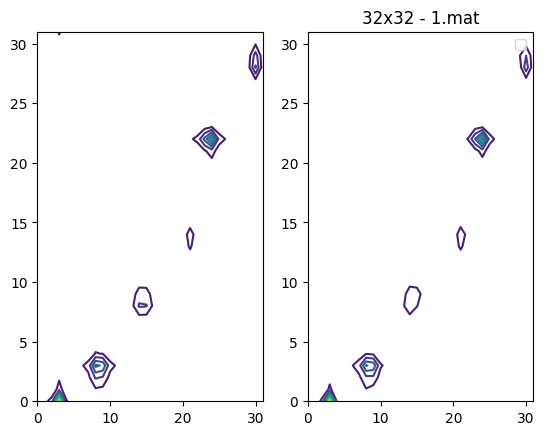

size=32x32  n=1000, RLNE=0.4047±0.1469, IntLin=0.9682±0.0345, time=7.87s


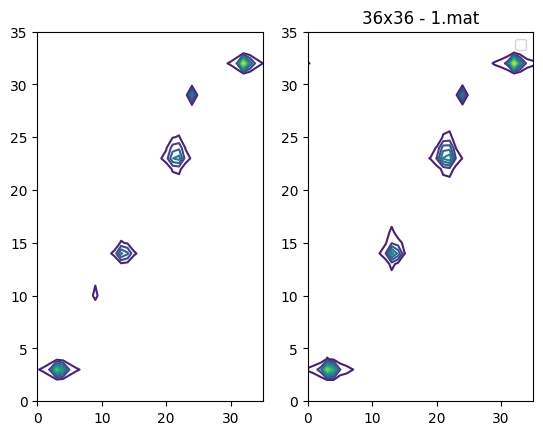

size=36x36  n=1000, RLNE=0.2077±0.0684, IntLin=0.9938±0.0049, time=7.85s


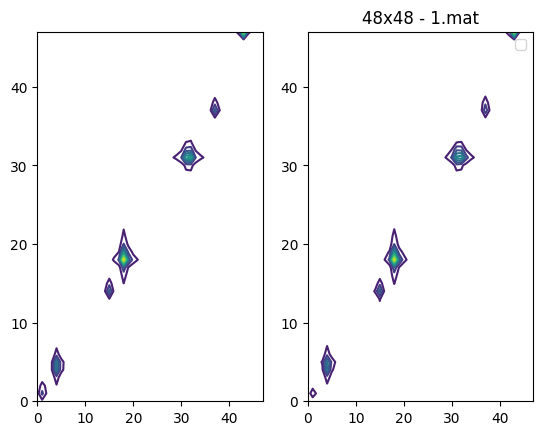

size=48x48  n=1000, RLNE=0.1462±0.0454, IntLin=0.9972±0.0021, time=8.73s


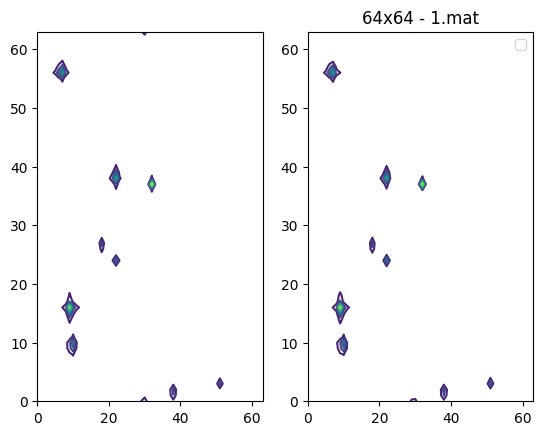

size=64x64  n=1000, RLNE=0.1174±0.0323, IntLin=0.9974±0.0019, time=10.25s


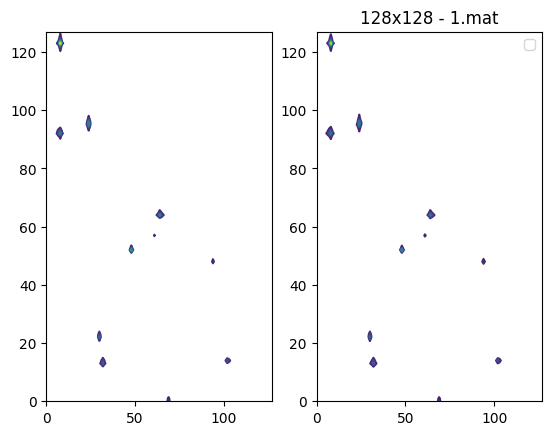

size=128x128  n=1000, RLNE=0.1414±0.0414, IntLin=0.9990±0.0006, time=22.97s


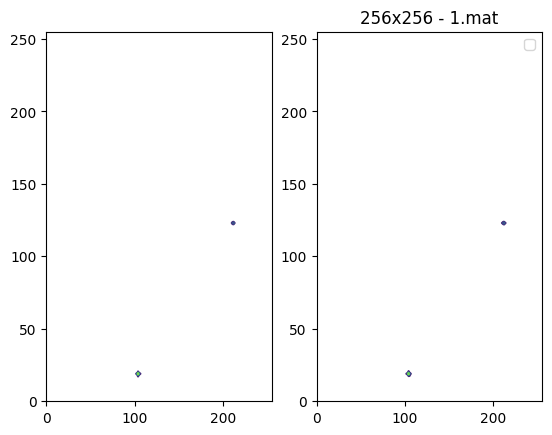

size=256x256  n=1000, RLNE=0.2505±0.1241, IntLin=0.9995±0.0003, time=86.21s


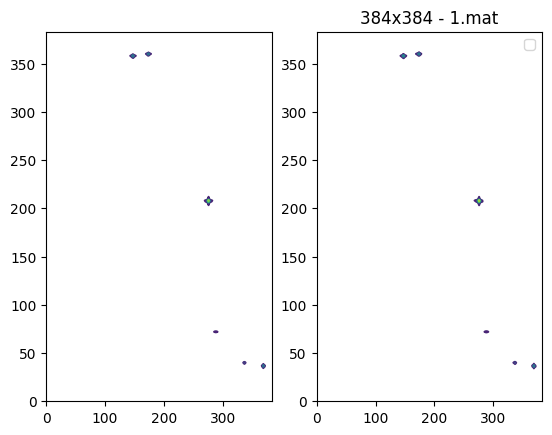

size=384x384  n=1000, RLNE=0.3060±0.1528, IntLin=0.9995±0.0004, time=239.78s


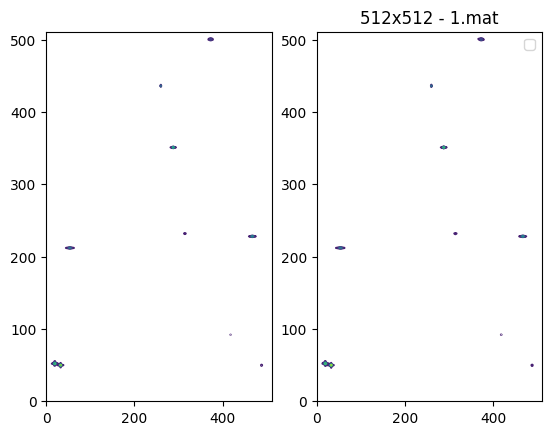

size=512x512  n=1000, RLNE=0.3216±0.1453, IntLin=0.9996±0.0005, time=309.33s


In [2]:
import math
import sys
from pathlib import Path

CODE_DIR = '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Python_Code/Res-Conformer'
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)
from utils import compute_recon_metrics, PEAK_MIN_HEIGHT

# ===================== 配置 =====================
TILE_SIZE = 64  # 训练尺寸
CHUNK_SIZE = 16  # 大图分块推理 batch chunk
MAX_FILES = None  # 每个尺寸评估样本数；可设为整数做快速测试
PEAK_MIN_HEIGHT = PEAK_MIN_HEIGHT  # 选峰阈值

DATA_ROOT = 'F:/GRA/Transformer/Robust_Experiment/Add_simula_experiment_data/256x256'
RESULTS_ROOT = '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/eval_results'
os.makedirs(RESULTS_ROOT, exist_ok=True)

INPUT_KEY = 'f_2d_nus_2c'
TARGET_KEY = 'f_2d_2c'
SAMPLED_KEY = 'fid_2d_nus_2c'
MASK_KEY = 'mask_2c'

DEFAULT_SIZE_DIRS = {
    '32x32':   '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/32x32',
    '36x36':   '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/36x36',
    '48x48':   '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/48x48',
    '64x64':   '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/64x64',
    '128x128': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/128x128',
    '256x256': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/256x256',
    '384x384': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/384x384',
    '512x512': '/mnt/DATA1/linjingjie/Transformer/Robust_Experiment/Add_simula_experiment_data/512x512',

}

def get_pad_size(h, w, tile_size=TILE_SIZE):
    if h <= tile_size and w <= tile_size:
        return tile_size, tile_size
    return math.ceil(h / tile_size) * tile_size, math.ceil(w / tile_size) * tile_size


def pad_array(arr, h_orig, w_orig, h_pad, w_pad):
    out = np.zeros((h_pad, w_pad, arr.shape[-1]), dtype=np.float32)
    out[:h_orig, :w_orig, :] = arr[:h_orig, :w_orig, :]
    return out


def split_tiles(tensor, tile_size=TILE_SIZE):
    b, h, w, c = tensor.shape
    nh, nw = h // tile_size, w // tile_size
    x = tensor.view(b, nh, tile_size, nw, tile_size, c)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    return x.view(b * nh * nw, tile_size, tile_size, c), nh, nw


def merge_tiles(tiles, batch_size, nh, nw, tile_size=TILE_SIZE):
    c = tiles.shape[-1]
    x = tiles.view(batch_size, nh, nw, tile_size, tile_size, c)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    return x.view(batch_size, nh * tile_size, nw * tile_size, c)


def forward_conformer_blocks(model, blocks, tiles, chunk_size=CHUNK_SIZE):
    outputs = []
    for i in range(0, tiles.shape[0], chunk_size):
        chunk = tiles[i:i + chunk_size]
        x = model.input_projection(chunk)
        for block in blocks:
            x = block(x)
        outputs.append(model.output_projection(x))
    return torch.cat(outputs, dim=0)


@torch.no_grad()
def cross_size_infer(model, inp, sampled, mask, tile_size=TILE_SIZE, chunk_size=CHUNK_SIZE):
    """<=64: 频域零填充；>64: 64x64 分块 Conformer + 全图 DC。"""
    _, h, w, _ = inp.shape
    _, h_orig, w_orig, _ = sampled.shape

    if h <= tile_size and w <= tile_size:
        _, out2 = model(inp, sampled, mask)
        return out2[:, :h_orig, :w_orig, :]

    tiles, nh, nw = split_tiles(inp, tile_size)
    out1_tiles = forward_conformer_blocks(model, model.conformer_block1, tiles, chunk_size)
    out1 = merge_tiles(out1_tiles, 1, nh, nw, tile_size)
    out1 = model.dc_layer(out1, sampled, mask)

    tiles, nh, nw = split_tiles(out1, tile_size)
    out2_tiles = forward_conformer_blocks(model, model.conformer_block2, tiles, chunk_size)
    out2 = merge_tiles(out2_tiles, 1, nh, nw, tile_size)
    out2 = model.dc_layer(out2, sampled, mask)
    return out2[:, :h_orig, :w_orig, :]


def load_mat_sample(mat_path):
    data = scio.loadmat(mat_path)
    inp = data[INPUT_KEY].astype(np.float32)
    target = data[TARGET_KEY].astype(np.float32)
    sampled = data[SAMPLED_KEY].astype(np.float32)
    mask = data[MASK_KEY].astype(np.float32)

    h_orig, w_orig = sampled.shape[0], sampled.shape[1]
    h_pad, w_pad = get_pad_size(h_orig, w_orig, TILE_SIZE)
    inp_p = pad_array(inp, h_orig, w_orig, h_pad, w_pad)
    # sampled/mask 保持原始尺寸，供 dc_layer 在有效区域做数据一致性
    return inp_p, target, sampled, mask, h_orig, w_orig

def format_mean_std(mean, std, decimals=4):
    return f'{mean:.{decimals}f}±{std:.{decimals}f}'

def discover_size_dirs(data_root, fallback=None):
    root = Path(data_root)
    if root.is_dir():
        found = {}
        for sub in sorted(root.iterdir()):
            if sub.is_dir() and any(p.suffix == '.mat' for p in sub.iterdir()):
                found[sub.name] = str(sub.resolve())
        if found:
            return found
    return fallback or {}


size_dirs = discover_size_dirs(DATA_ROOT, DEFAULT_SIZE_DIRS)
print('评估尺寸目录:', size_dirs)

loaded_model = loaded_model.to(device)
loaded_model.eval()

all_results = {}
for size_label, directory in size_dirs.items():
    files = sorted([f for f in os.listdir(directory) if f.endswith('.mat')])
    if MAX_FILES is not None:
        files = files[:MAX_FILES]

    rlne_list = []
    intensity_linearity_list = []
    start = time.perf_counter()
    flag = 1
    for fname in files:
        inp_p, target, sampled, mask, h_orig, w_orig = load_mat_sample(os.path.join(directory, fname))

        inp_t = torch.tensor(inp_p, dtype=torch.float32).unsqueeze(0).to(device)
        sampled_t = torch.tensor(sampled, dtype=torch.float32).unsqueeze(0).to(device)
        mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).to(device)
        out = cross_size_infer(loaded_model, inp_t, sampled_t, mask_t, TILE_SIZE, CHUNK_SIZE)
        pred = out.squeeze(0).detach().cpu().numpy()

        if flag:
            plt.subplot(1, 2, 1)
            plt.contour(abs(target[..., 0]+1j*target[..., 1]), levels=10)
            plt.subplot(1, 2, 2)
            plt.contour(abs(pred[..., 0]+1j*pred[..., 1]), levels=10)
            plt.title(f'{size_label} - {fname}')
            plt.legend(['Target', 'Predicted'])
            plt.show()
            flag = 0

        target_crop = target[:h_orig, :w_orig, :]
        rlne, intensity_linearity = compute_recon_metrics(
            target_crop, pred, min_peak=PEAK_MIN_HEIGHT
        )
        rlne_list.append(rlne)
        intensity_linearity_list.append(intensity_linearity)

    elapsed = time.perf_counter() - start
    all_results[size_label] = {
        'mean_rlne': float(np.mean(rlne_list)),
        'std_rlne': float(np.std(rlne_list)),
        'rlne_list': rlne_list,
        'mean_intensity_linearity': float(np.mean(intensity_linearity_list)),
        'std_intensity_linearity': float(np.std(intensity_linearity_list)),
        'intensity_linearity_list': intensity_linearity_list,
        'time_s': elapsed,
        'num_samples': len(rlne_list),
    }
    print(  f'size={size_label}  '
            f'n={len(rlne_list)}, RLNE={format_mean_std(all_results[size_label]["mean_rlne"], all_results[size_label]["std_rlne"])}, '
            f'IntLin={format_mean_std(all_results[size_label]["mean_intensity_linearity"], all_results[size_label]["std_intensity_linearity"])}, '
            f'time={elapsed:.2f}s'
        )
